In [48]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [49]:
F = 96485 # C/mol
R = 8.31 # J/(mol * k)
T = 300 # K
V_m = -0.07 # V
n = 5
k0_1 = 2 # ms^-1
k0_2 = 1 # ms^-1
z_1 = 1
z_2 = 0
c_i = 0.0000001 # M
c_e = .04 # M
s_0 = 20
P_Ca = .00001 # ms^-1
V_0 = -0.07 # V
V_neuron = 523.6 # μm^3
V_neuron_L = V_neuron * 0.000000000000001 # L

In [50]:
def k_1(V):
    return k0_1 * np.exp(F * z_1 * V / R / T)

def k_2(V):
    return k0_2 * np.exp(F * z_2 * V / R / T)

def o_hat(V):
    return k_1(V) / (k_1(V)+k_2(V))


def calcium_current_to_molar_per_second(I):
    return -I / (2 * F * V_neuron_L)

def dParams(t, params):
    V = params[0]
    o = params[1]
    dodt = k_1(V) * (1-o) -k_2(V) * o

    i = P_Ca * 4 * F**2 / R / T * V * (c_i - c_e * np.exp(-2*F*V / R / T)) / (1 - np.exp(-2*F*V / R / T))
    I_ca = s_0 * i * o**n
    dVdt = -I_ca
    
    return np.array([dVdt, dodt])


In [51]:
# integrate
params_0 = np.array([V_0, o_hat(V_0)])
t_span = [0,0.08]
sol = solve_ivp(dParams, t_span, params_0)

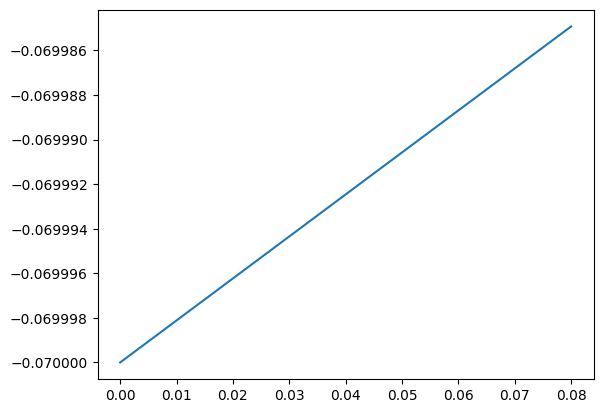

In [52]:
plt.plot(sol.t, sol.y[0])

In [53]:
dParams(0, params_0)

array([0.00018843, 0.        ])